In [1]:
import logging

In [2]:
logging.basicConfig(level=logging.INFO)

In [3]:
import matplotlib.pyplot as plt
import numpy as np

In [4]:
from chromatic_weak_lensing import MainSequence
from chromatic_weak_lensing import Blackbody
from chromatic_weak_lensing.fsps import FSPS
from chromatic_weak_lensing.btsettl import BTSettl

In [5]:
blackbody = Blackbody()
fsps = FSPS()
btsettl = BTSettl()

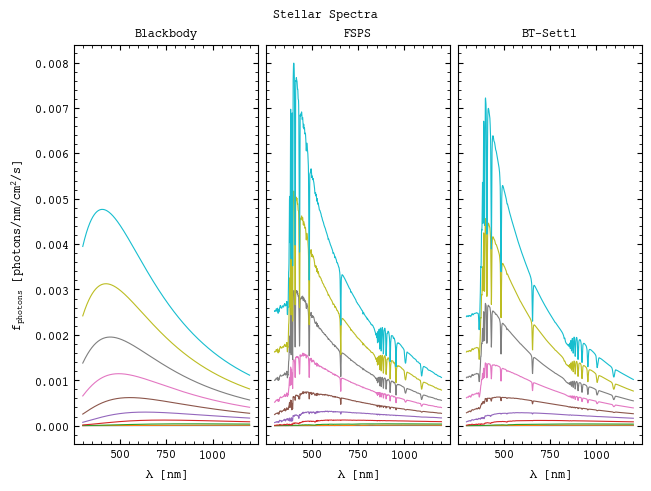

In [6]:
fig, axs = plt.subplots(
    1, 3,
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

axs[0].set_xlabel("$\lambda$ [$nm$]")
axs[0].set_ylabel("$f_{photons}$ [$photons/nm/cm^2/s$]")
axs[0].set_title("Blackbody")

axs[1].set_xlabel("$\lambda$ [$nm$]")
# axs[1].set_ylabel("$f_{photons}$ [$photons/nm/cm^2/s$]")
axs[1].set_title("FSPS")

axs[2].set_xlabel("$\lambda$ [$nm$]")
# axs[2].set_ylabel("$f_{photons}$ [$photons/nm/cm^2/s$]")
axs[2].set_title("BT-Settl")


fig.suptitle("Stellar Spectra")


n_spec = 10
masses = np.linspace(0.2, 2.0, n_spec)

wl = np.linspace(300, 1200, 1000)

for mass in masses:
    sparams = MainSequence.get_params(mass)

    blackbody_params = blackbody.get_params(sparams)
    blackbody_spec = blackbody.get_spectrum(*blackbody_params)

    fsps_params = fsps.get_params(sparams)
    fsps_spec = fsps.get_spectrum(*fsps_params)

    btsettl_params = btsettl.get_params(sparams)
    btsettl_spec = btsettl.get_spectrum(*btsettl_params)
    
    axs[0].plot(wl, blackbody_spec(wl))
    axs[1].plot(wl, fsps_spec(wl))
    axs[2].plot(wl, btsettl_spec(wl))

plt.show()